   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 MB 7.7 MB/s eta 0:00:00
Running MHE simulation...
  step 100/499
  step 200/499
  step 300/499
  step 400/499
Done.

MHE Performance
Horizon M            : 10 steps
Mean arc-length error: 0.283 m
Mean lateral error   : 0.249 m
Mean solve time      : 1964.3 ms
Max  solve time      : 3474.9 ms
Sampling budget      : 10.0 ms  (100 Hz)
Real-time feasible   : False


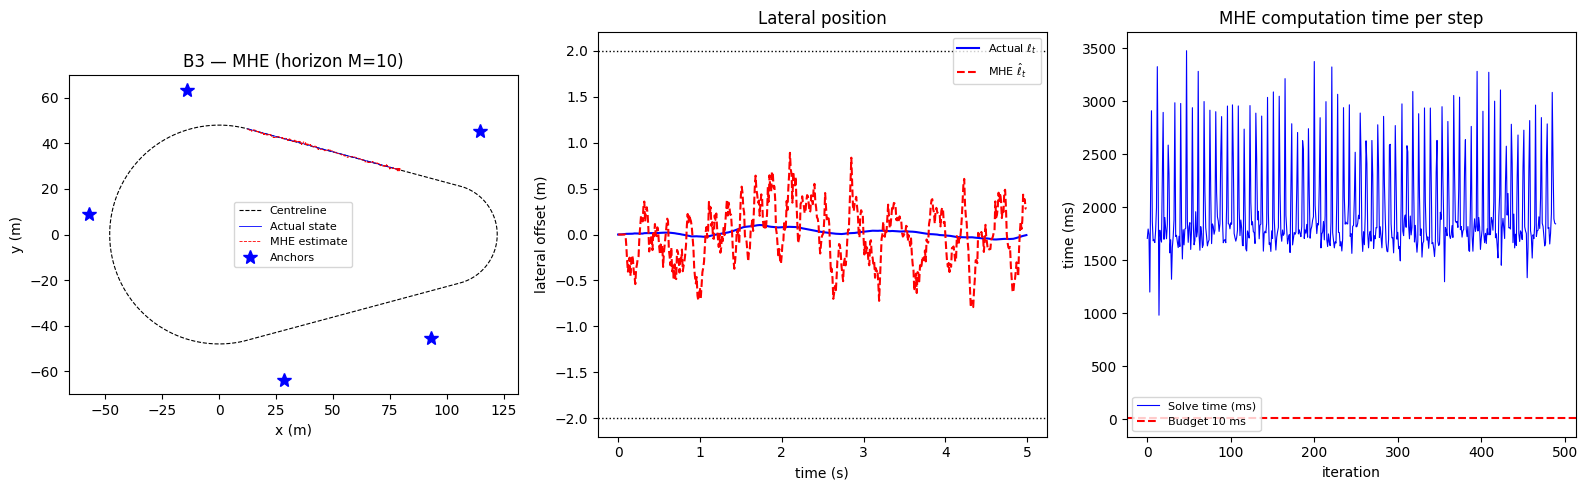

In [1]:
!pip install casadi -q

import numpy as np
import matplotlib.pyplot as plt
import casadi.casadi as cs
import scipy.optimize as sopt
import time

np.random.seed(42)

# ── Track geometry (A1, modelling.ipynb — ChenhuiCui) ─────────────────────
R_outer = 50.0; r_inner = 46.0; rho = 20.0; d = 100.0
R_A = (R_outer + r_inner) / 2
w   = (R_outer - r_inner) / 2
R_B = rho + w
alpha = np.arcsin((R_A - R_B) / d)
cos_a  = np.cos(alpha);  sin_a = np.sin(alpha)
l_tan  = np.sqrt(d**2 - (R_A - R_B)**2)
L      = 2*l_tan + R_A*(np.pi + 2*alpha) + R_B*(np.pi - 2*alpha)
s1     = l_tan;  s2 = s1 + R_B*(np.pi - 2*alpha);  s3 = s2 + l_tan

A_centre = np.array([0.0, 0.0]);  B_centre = np.array([d, 0.0])
A_top    = A_centre + R_A * np.array([sin_a,  cos_a])
B_bot    = B_centre + R_B * np.array([sin_a, -cos_a])

def s_to_xy(s):
    s = s % L
    if s < s1:
        return A_top + s * np.array([cos_a, -sin_a])
    elif s < s2:
        theta = (np.pi/2 - alpha) - (s - s1) / R_B
        return B_centre + R_B * np.array([np.cos(theta), np.sin(theta)])
    elif s < s3:
        return B_bot + (s - s2) * np.array([-cos_a, -sin_a])
    else:
        theta = (-np.pi/2 + alpha) - (s - s3) / R_A
        return A_centre + R_A * np.array([np.cos(theta), np.sin(theta)])

def s_to_normal(s):
    s = s % L
    if s < s1:
        return np.array([sin_a,  cos_a])
    elif s < s2:
        theta = (np.pi/2 - alpha) - (s - s1) / R_B
        return np.array([np.cos(theta), np.sin(theta)])
    elif s < s3:
        return np.array([sin_a, -cos_a])
    else:
        theta = (-np.pi/2 + alpha) - (s - s3) / R_A
        return np.array([np.cos(theta), np.sin(theta)])

def sl_to_xy(s, ell):
    return s_to_xy(s) + ell * s_to_normal(s)

# ── Problem data (A2/A3/A4, modelling.ipynb — ChenhuiCui) ─────────────────
dt     = 0.01
phi_vs = 0.999
phi_1  = 0.9
k2     = 10.0

anchors = np.array([
    [ -14.3,  63.6],
    [ 114.3,  45.5],
    [  28.6, -63.6],
    [ -57.1,   9.1],
    [  92.9, -45.5],
])
ny = len(anchors)
nx = 4
nw = 2   # noise dimension

A_mat = np.array([
    [1,       0,     dt,       0   ],
    [0,       1,     0,        dt  ],
    [0,       0,     phi_vs,   0   ],
    [0, -dt*k2,     0,        phi_1],
])
G = np.array([[0,0],[0,0],[1,0],[0,1]])

Q      = np.diag([0.5, 0.003])   # confirmed by A4
R_meas = 1.5**2
Qbar   = G @ Q @ G.T

# ── True dynamics (numpy) ──────────────────────────────────────────────────
def f_true(x, w):
    x_plus    = A_mat @ x + G @ w
    x_plus[1] = np.clip(x_plus[1], -2.0, 2.0)
    x_plus[2] = np.clip(x_plus[2],  0.001, 25.0)
    return x_plus

# ── Measurement function (numpy) ──────────────────────────────────────────
def h_meas(x):
    s_val   = float(x[0])
    ell_val = float(x[1])
    pos = sl_to_xy(s_val, ell_val)
    return np.array([np.linalg.norm(pos - anchors[i]) for i in range(ny)])

# ── B3: MHE formulation ────────────────────────────────────────────────────
# Following 2_bayesian_fie.ipynb (lecturer's Bayesian FIE approach):
#   Minimise over z = [x_0,...,x_M, w_0,...,w_{M-1}]:
#     ell_x0(x_0) + sum_{t=0}^{M-1} [ ell_w(w_t) + ell_v(y_t - h(x_t)) ]
#   subject to:  x_{t+1} = A*x_t + G*w_t  (linear dynamics)
#   with bounds: ell in [-2,2], vs in [0,25]  (HARD constraints — key MHE advantage)
#
# Horizon M=10: trades off accuracy vs computation time.
# Arrival cost: P0 diagonal (first version; can be replaced by EKF covariance).

M    = 10    # MHE horizon (steps)
P0_mhe = np.diag([100.0, 1.0, 25.0, 0.5])   # arrival cost covariance

def ell_x0(x0, x0_bar, P0_inv):
    dx = x0 - x0_bar
    return dx @ P0_inv @ dx

def ell_w(w):
    return w @ np.linalg.inv(Q) @ w

def ell_v(v):
    return v @ v / R_meas

def cost_mhe(z_flat, y_window, x0_bar, P0_inv):
    xs = z_flat[:nx*(M+1)].reshape(M+1, nx)
    ws = z_flat[nx*(M+1):].reshape(M, nw)
    e  = ell_x0(xs[0], x0_bar, P0_inv)
    for t in range(M):
        v_t = y_window[t] - h_meas(xs[t])
        e  += ell_w(ws[t]) + ell_v(v_t)
    return float(e)

def dyn_constraint_mhe(z_flat):
    xs = z_flat[:nx*(M+1)].reshape(M+1, nx)
    ws = z_flat[nx*(M+1):].reshape(M, nw)
    c  = []
    for t in range(M):
        x_next = A_mat @ xs[t] + G @ ws[t]
        c.extend((xs[t+1] - x_next).tolist())
    return np.array(c)

# Bounds: ell in [-2,2], vs in [0,25], no bound on s or vl
s_bound   = (None, None)
ell_bound = (-2.0, 2.0)
vs_bound  = (0.001, 25.0)
vl_bound  = (None, None)

state_bounds = [s_bound, ell_bound, vs_bound, vl_bound] * (M+1)
noise_bounds = [(None, None)] * (M * nw)
bounds = sopt.Bounds(
    lb=[b[0] if b[0] is not None else -np.inf for b in state_bounds + noise_bounds],
    ub=[b[1] if b[1] is not None else  np.inf for b in state_bounds + noise_bounds]
)

constr = sopt.NonlinearConstraint(dyn_constraint_mhe, 0, 0)

# ── Simulation ─────────────────────────────────────────────────────────────
N          = 500    # shorter run for MHE (computationally heavier)
x_t        = np.array([0.0, 0.0, 10.0, 0.0])
x_t_mhe    = np.array([0.0, 0.0, 10.0, 0.0])

x_cache      = np.zeros((N, nx))
x_mhe_cache  = np.zeros((N, nx))
y_buffer     = []
x_buffer     = [x_t_mhe.copy()]

x_cache[0]     = x_t
x_mhe_cache[0] = x_t_mhe

solve_times = []

print("Running MHE simulation...")
for t in range(N-1):

    # true measurement
    v_t = np.random.normal(0, 1.5, ny)
    y_t = h_meas(x_t) + v_t
    y_buffer.append(y_t)

    # MHE: solve once window is full
    if len(y_buffer) >= M:
        y_window = y_buffer[-M:]
        x0_bar   = x_buffer[-M]
        P0_inv   = np.linalg.inv(P0_mhe)

        # initial guess: propagate from x0_bar
        xs_guess = np.zeros((M+1, nx))
        xs_guess[0] = x0_bar
        for s in range(M):
            xs_guess[s+1] = A_mat @ xs_guess[s]
        ws_guess = np.zeros((M, nw))
        z0 = np.concatenate([xs_guess.flatten(), ws_guess.flatten()])

        t0 = time.time()
        res = sopt.minimize(
            cost_mhe,
            z0,
            args=(y_window, x0_bar, P0_inv),
            method='SLSQP',
            constraints=[constr],
            bounds=bounds,
            options={'maxiter': 200, 'ftol': 1e-6}
        )
        solve_times.append((time.time() - t0) * 1000)

        xs_star    = res.x[:nx*(M+1)].reshape(M+1, nx)
        x_t_mhe    = xs_star[-1]

    x_mhe_cache[t+1] = x_t_mhe
    x_buffer.append(x_t_mhe.copy())

    # true dynamics
    w_t     = np.array([np.random.normal(0, np.sqrt(Q[0,0])),
                        np.random.normal(0, np.sqrt(Q[1,1]))])
    vs_new  = phi_vs * x_t[2] + 10.0*(1-phi_vs) + w_t[0]
    vl_new  = phi_1  * x_t[3] - dt*k2*x_t[1]   + w_t[1]
    vs_new  = np.clip(vs_new,  0.001, 25.0)
    vl_new  = np.clip(vl_new, -0.55,  0.55)
    ell_new = np.clip(x_t[1] + dt*x_t[3], -2.0, 2.0)
    x_t     = np.array([x_t[0] + dt*x_t[2], ell_new, vs_new, vl_new])
    x_cache[t+1] = x_t

    if (t+1) % 100 == 0:
        print(f"  step {t+1}/{N-1}")

print("Done.")

# ── Performance ────────────────────────────────────────────────────────────
valid = slice(M, N)
arc_err = np.abs(x_cache[valid, 0] - x_mhe_cache[valid, 0])
lat_err = np.abs(x_cache[valid, 1] - x_mhe_cache[valid, 1])

print("\n" + "="*55)
print("MHE Performance")
print("="*55)
print(f"Horizon M            : {M} steps")
print(f"Mean arc-length error: {np.mean(arc_err):.3f} m")
print(f"Mean lateral error   : {np.mean(lat_err):.3f} m")
print(f"Mean solve time      : {np.mean(solve_times):.1f} ms")
print(f"Max  solve time      : {np.max(solve_times):.1f} ms")
print(f"Sampling budget      : {dt*1000:.1f} ms  (100 Hz)")
print(f"Real-time feasible   : {np.mean(solve_times) < dt*1000}")
print("="*55)

# ── Plots ───────────────────────────────────────────────────────────────────
t_ax = np.arange(N) * dt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

s_vals   = np.linspace(0, L, 1000)
track_xy = np.array([s_to_xy(s) for s in s_vals])
true_xy  = np.array([sl_to_xy(float(x_cache[t,0]), float(x_cache[t,1])) for t in range(N)])
mhe_xy   = np.array([sl_to_xy(float(x_mhe_cache[t,0]), float(x_mhe_cache[t,1])) for t in range(N)])

axes[0].plot(track_xy[:,0], track_xy[:,1], 'k--', lw=0.8, label='Centreline')
axes[0].plot(true_xy[:,0],  true_xy[:,1],  'b',   lw=0.6, label='Actual state')
axes[0].plot(mhe_xy[:,0],   mhe_xy[:,1],   'r--', lw=0.6, label='MHE estimate')
for i in range(ny):
    axes[0].plot(anchors[i,0], anchors[i,1], 'b*', ms=10,
                 label='Anchors' if i==0 else None)
axes[0].set_aspect('equal')
axes[0].legend(fontsize=8)
axes[0].set_xlabel('x (m)');  axes[0].set_ylabel('y (m)')
axes[0].set_title(f'B3 — MHE (horizon M={M})')

axes[1].plot(t_ax,      x_cache[:,1],     'b',   label=r'Actual $\ell_t$')
axes[1].plot(t_ax,      x_mhe_cache[:,1], 'r--', label=r'MHE $\hat{\ell}_{t}$')
axes[1].axhline( 2.0, color='k', ls=':', lw=1)
axes[1].axhline(-2.0, color='k', ls=':', lw=1)
axes[1].legend(fontsize=8)
axes[1].set_xlabel('time (s)');  axes[1].set_ylabel('lateral offset (m)')
axes[1].set_title('Lateral position')

axes[2].plot(solve_times, 'b-', lw=0.8, label='Solve time (ms)')
axes[2].axhline(dt*1000, color='r', ls='--', lw=1.5,
                label=f'Budget {dt*1000:.0f} ms')
axes[2].set_xlabel('iteration');  axes[2].set_ylabel('time (ms)')
axes[2].set_title('MHE computation time per step')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()